In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../results', exist_ok=True)
os.makedirs('../figures/final', exist_ok=True)

model = joblib.load('../results/cece_xgb_model.pkl')
print('Model loaded')

labels    = pd.read_csv('../data/processed/engraftment_labels.csv')
causal    = pd.read_csv('../data/processed/causal/causal_effects.csv')
growth    = pd.read_csv('../data/processed/micom_growth_results.csv')
exchanges = pd.read_csv('../data/processed/micom_exchange_results.csv')
smillie   = pd.read_csv('../data/processed/smillie_engraftment_auc.csv')
scfa      = pd.read_csv('../data/processed/micom_scfa_scores.csv')

SCFA_COLS = [c for c in [
    'butyrate_flux', 'propionate_flux', 'acetate_flux',
    'lactate_flux',  'succinate_flux',  'formate_flux',
    'therapeutic_score'
] if c in scfa.columns]

keystones = {}
networks  = {}
for cond in ['CD', 'UC', 'Healthy']:
    keystones[cond] = pd.read_csv(f'../results/networks/keystones_{cond}.csv')
    networks[cond]  = nx.read_gexf(f'../results/networks/{cond}_network.gexf')

train_labels = labels[labels['split'] == 'train']
pod_prob = (
    train_labels.groupby('species')['engrafted']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'podlesny_prob', 'count': 'n_obs'})
    .reset_index()
)
pod_prob = pod_prob[pod_prob['n_obs'] >= 3].merge(
    smillie[['species', 'smillie_engraftment_prob']], on='species', how='left'
)
pod_prob['causal_engraftment_prob'] = np.where(
    pod_prob['smillie_engraftment_prob'].notna(),
    0.6 * pod_prob['podlesny_prob'] + 0.4 * pod_prob['smillie_engraftment_prob'],
    pod_prob['podlesny_prob']
)

resource = (
    growth.groupby('species')['growth_rate']
    .mean().rename('resource_accessibility').reset_index()
)

secretions = exchanges[exchanges['flux'] > 0]
crossfeed  = (
    secretions.groupby('species')['flux']
    .sum().rename('crossfeeding_synergy').reset_index()
)
max_f = crossfeed['crossfeeding_synergy'].max()
if max_f > 0:
    crossfeed['crossfeeding_synergy'] /= max_f

def kc(sp, networks, keystones, top_n=10):
    s = []
    for c in ['CD', 'UC', 'Healthy']:
        G  = networks[c]
        ks = keystones[c].head(top_n)['species'].tolist()
        if sp not in G: s.append(0.0); continue
        nb = list(G.neighbors(sp))
        if not nb: s.append(0.0); continue
        s.append(len([n for n in nb if n in ks and
                       G[sp][n].get('interaction') == 'competition']) / len(nb))
    return np.mean(s)


def no(sp, networks):
    s = []
    for c in ['CD', 'UC', 'Healthy']:
        G = networks[c]
        if sp not in G: s.append(0.0); continue
        w = [d['weight'] for _, _, d in G.edges(sp, data=True)
             if d.get('interaction') == 'mutualism']
        s.append(np.mean(w) if w else 0.0)
    return np.mean(s)


species_list = pod_prob['species'].tolist()
print(f'Building master feature table for {len(species_list)} species...')

master_rows = []
for sp in species_list:
    row = {'species': sp}

    v = pod_prob[pod_prob['species'] == sp]['causal_engraftment_prob'].values
    row['causal_engraftment_prob'] = float(v[0]) if len(v) else 0.0

    row['keystone_conflict_mean'] = kc(sp, networks, keystones)
    row['niche_overlap_mean']     = no(sp, networks)

    v = resource[resource['species'] == sp]['resource_accessibility'].values
    row['resource_accessibility'] = float(v[0]) if len(v) else 0.0

    v = crossfeed[crossfeed['species'] == sp]['crossfeeding_synergy'].values
    row['crossfeeding_synergy'] = float(v[0]) if len(v) else 0.0

    v = causal[causal['species'] == sp]['ace'].values
    row['causal_ace'] = float(v[0]) if len(v) else 0.0
    v = causal[causal['species'] == sp]['significant'].values
    row['causal_sig'] = int(v[0]) if len(v) else 0

    sp_scfa = scfa[scfa['species'] == sp]
    for col in SCFA_COLS:
        row[col] = float(sp_scfa[col].values[0]) if not sp_scfa.empty else 0.0

    master_rows.append(row)

master = pd.DataFrame(master_rows).fillna(0)
print(f'Master feature table: {master.shape}')
print('Done')

Model loaded
Building master feature table for 208 species...
Master feature table: (208, 15)
Done


In [2]:
from sklearn.preprocessing import MinMaxScaler

SCORE_COLS = [c for c in [
    'causal_engraftment_prob', 'keystone_conflict_mean',
    'niche_overlap_mean',      'resource_accessibility',
    'crossfeeding_synergy',    'causal_ace'
] if c in master.columns]

scaler             = MinMaxScaler()
master[SCORE_COLS] = scaler.fit_transform(master[SCORE_COLS])

master['keystone_conflict_mean'] = 1 - master['keystone_conflict_mean']
master['niche_overlap_mean']     = 1 - master['niche_overlap_mean']

WEIGHTS = {
    'causal_engraftment_prob': 0.30,
    'causal_ace':              0.20,
    'keystone_conflict_mean':  0.15,
    'niche_overlap_mean':      0.10,
    'resource_accessibility':  0.15,
    'crossfeeding_synergy':    0.10,
}

master['cece_score'] = sum(
    WEIGHTS.get(col, 0.0) * master[col]
    for col in SCORE_COLS
)

master = master.sort_values('cece_score', ascending=False).reset_index(drop=True)
master.to_csv('../data/processed/cece_final_scores.csv', index=False)

print(f'CECE scores saved: {len(master)} species')
print(f'Score range: {master["cece_score"].min():.4f} to {master["cece_score"].max():.4f}')
print(f'\nTop 15 species by CECE score:')
print(master[['species', 'cece_score'] + SCORE_COLS].head(15).to_string(index=False))

CECE scores saved: 208 species
Score range: 0.1687 to 0.7872

Top 15 species by CECE score:
                        species  cece_score  causal_engraftment_prob  keystone_conflict_mean  niche_overlap_mean  resource_accessibility  crossfeeding_synergy  causal_ace
               Blautia_wexlerae    0.787198                 0.862505                1.000000            1.000000                0.434996              0.239753    0.946110
               Roseburia_faecis    0.755423                 0.905342                1.000000            1.000000                0.595885              0.713885    0.365248
                  Blautia_obeum    0.752116                 0.955943                1.000000            1.000000                0.453316              0.240802    0.616278
            Anaerostipes_hadrus    0.714611                 0.892914                0.811868            0.272469                0.602376              0.368019    0.852756
Fusicatenibacter_saccharivorans    0.693725          

In [3]:
pod_wide = pd.read_pickle('../data/processed/podlesny_wide.pkl')
pod_meta = pd.read_csv('../data/processed/podlesny_meta_split.csv')

print("Sample_Type values in meta:")
print(pod_meta['Sample_Type'].value_counts())
print("\nSplit distribution for donor rows:")
print(
    pod_meta[pod_meta['Sample_Type'].str.strip().str.lower() == 'donor']['split']
    .value_counts(dropna=False)
)

all_donors = pod_meta[
    pod_meta['Sample_Type'].str.strip().str.lower() == 'donor'
]['Name'].dropna().values

donors = [d for d in all_donors if d in pod_wide.index]

print(f'\nDonors available for GA: {len(donors)}')

ALL_FEATURES = [c for c in [
    'causal_engraftment_prob', 'keystone_conflict_mean',
    'niche_overlap_mean',      'resource_accessibility',
    'crossfeeding_synergy',    'causal_ace', 'causal_sig',
    'donor_abundance'
] + SCFA_COLS if c in master.columns or c == 'donor_abundance']

print(f'Prediction features ({len(ALL_FEATURES)}): {ALL_FEATURES}')

Sample_Type values in meta:
Sample_Type
Post            826
Donor           297
Pre No-ABx      216
Pre Post-ABx     77
Name: count, dtype: int64

Split distribution for donor rows:
split
train    297
Name: count, dtype: int64

Donors available for GA: 297
Prediction features (15): ['causal_engraftment_prob', 'keystone_conflict_mean', 'niche_overlap_mean', 'resource_accessibility', 'crossfeeding_synergy', 'causal_ace', 'causal_sig', 'donor_abundance', 'butyrate_flux', 'propionate_flux', 'acetate_flux', 'lactate_flux', 'succinate_flux', 'formate_flux', 'therapeutic_score']


In [4]:
import random

POP_SIZE    = 100
N_GEN       = 60
CROSSOVER_R = 0.8
MUTATION_R  = 0.08
MIN_SPECIES = 5
MAX_SPECIES = 20

random.seed(42)
np.random.seed(42)


def build_X(species_subset, donor_profile):
    rows = []
    for sp in species_subset:
        sp_row = master[master['species'] == sp]
        if sp_row.empty:
            continue
        row = sp_row.iloc[0].to_dict()
        row['donor_abundance'] = float(donor_profile.get(sp, 0.0))
        rows.append(row)
    if not rows:
        return None
    feat_df = pd.DataFrame(rows)
    cols    = [c for c in ALL_FEATURES if c in feat_df.columns]
    return feat_df[cols].fillna(0)


def fitness(chromosome, species_pool, donor_profile, size_penalty=0.005):
    selected = [sp for sp, bit in zip(species_pool, chromosome) if bit == 1]
    n        = len(selected)
    if n < MIN_SPECIES or n > MAX_SPECIES:
        return 0.0
    X = build_X(selected, donor_profile)
    if X is None or len(X) == 0:
        return 0.0
    proba = model.predict_proba(X)[:, 1].mean()
    return float(proba - size_penalty * (n - MIN_SPECIES))


def init_pop(n_sp):
    pop = []
    for _ in range(POP_SIZE):
        n   = random.randint(MIN_SPECIES, min(MAX_SPECIES, n_sp))
        idx = random.sample(range(n_sp), n)
        c   = [0] * n_sp
        for i in idx: c[i] = 1
        pop.append(c)
    return pop


def tournament(pop, fits, k=3):
    contestants = random.sample(range(len(pop)), k)
    return pop[max(contestants, key=lambda i: fits[i])][:]


def crossover(p1, p2):
    if random.random() > CROSSOVER_R:
        return p1[:], p2[:]
    pt = random.randint(1, len(p1) - 1)
    return p1[:pt] + p2[pt:], p2[:pt] + p1[pt:]


def mutate(c):
    return [1 - bit if random.random() < MUTATION_R else bit for bit in c]


def run_ga(donor_profile, n_gen=N_GEN):
    present    = donor_profile[donor_profile > 0.001]
    ga_species = sorted(set(present.index) & set(master['species']))

    if len(ga_species) < MIN_SPECIES:
        return [], 0.0, []

    n_sp   = len(ga_species)
    pop    = init_pop(n_sp)
    best_c = None
    best_f = -1.0
    hist   = []

    for gen in range(n_gen):
        fits     = [fitness(c, ga_species, present) for c in pop]
        gen_best = max(fits)
        hist.append(gen_best)

        if gen_best > best_f:
            best_f = gen_best
            best_c = pop[fits.index(gen_best)][:]

        new_pop = []
        while len(new_pop) < POP_SIZE:
            c1, c2 = crossover(tournament(pop, fits), tournament(pop, fits))
            new_pop.append(mutate(c1))
            if len(new_pop) < POP_SIZE:
                new_pop.append(mutate(c2))
        pop = new_pop

    best_species = [sp for sp, bit in zip(ga_species, best_c) if bit == 1]
    return best_species, best_f, hist


print('GA functions defined')
print(f'Parameters: pop={POP_SIZE}, generations={N_GEN}, '
      f'min_species={MIN_SPECIES}, max_species={MAX_SPECIES}')

GA functions defined
Parameters: pop=100, generations=60, min_species=5, max_species=20


Donor: FRICKE_16B
Donor carries 46 species
Available for GA: 45 species (in CECE scores)
Running 60 generations...

Optimal consortium: 9 species
GA fitness: 0.7789

Consortium:
  Bacteroides_finegoldii  (CECE=0.587)
  Blautia_obeum  (CECE=0.752)
  Blautia_wexlerae  (CECE=0.787)
  Candidatus_Stoquefichus_sp_KLE1796  (CECE=0.572)
  Collinsella_aerofaciens  (CECE=0.513)
  Dorea_longicatena  (CECE=0.565)
  Faecalibacterium_prausnitzii  (CECE=0.563)
  Roseburia_faecis  (CECE=0.755)
  Ruthenibacterium_lactatiformans  (CECE=0.539)


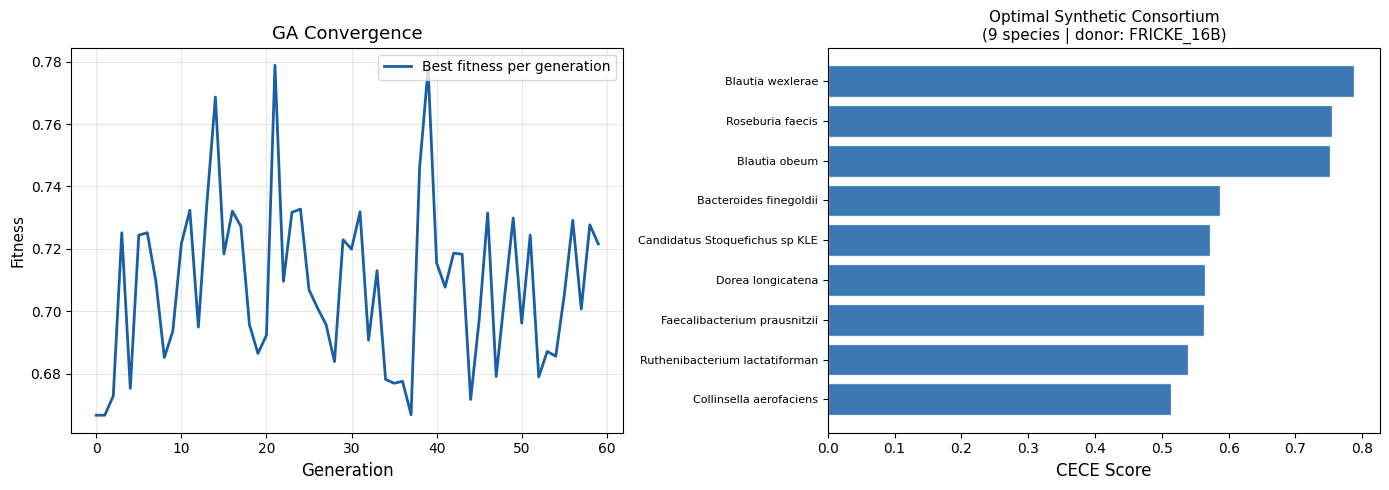

Figures saved


In [5]:
import matplotlib.pyplot as plt

donor_id = donors[0]
profile  = pod_wide.loc[donor_id]
if isinstance(profile, pd.DataFrame):
    profile = profile.iloc[0]

present    = profile[profile > 0.001]
ga_species = sorted(set(present.index) & set(master['species']))

print(f'Donor: {donor_id}')
print(f'Donor carries {len(present)} species')
print(f'Available for GA: {len(ga_species)} species (in CECE scores)')
print(f'Running {N_GEN} generations...')

best_species, best_fitness, history = run_ga(profile, n_gen=N_GEN)

print(f'\nOptimal consortium: {len(best_species)} species')
print(f'GA fitness: {best_fitness:.4f}')
print(f'\nConsortium:')
for sp in best_species:
    sc = master[master['species'] == sp]['cece_score'].values
    print(f'  {sp}  (CECE={sc[0]:.3f})' if len(sc) else f'  {sp}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')

ax = axes[0]
ax.set_facecolor('white')
ax.plot(history, '#185FA5', lw=2, label='Best fitness per generation')
ax.set_xlabel('Generation', fontsize=12)
ax.set_ylabel('Fitness', fontsize=11)
ax.set_title('GA Convergence', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

ax = axes[1]
ax.set_facecolor('white')
cons_df = master[master['species'].isin(best_species)].sort_values(
    'cece_score', ascending=True
)
ax.barh(
    [sp.replace('_', ' ')[:30] for sp in cons_df['species']],
    cons_df['cece_score'],
    color='#185FA5', alpha=0.85, edgecolor='white'
)
ax.set_xlabel('CECE Score', fontsize=12)
ax.set_title(f'Optimal Synthetic Consortium\n({len(best_species)} species | donor: {donor_id})',
             fontsize=11)
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('../figures/final/Fig_GA_convergence.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('../figures/final/Fig_consortium.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('Figures saved')

In [7]:
all_consortia = []

n_run = min(20, len(donors))
print(f'Running GA for {n_run} test donors...')
print('(~30s per donor)\n')

for donor_id in donors[:n_run]:
    if donor_id not in pod_wide.index:
        continue

    prof = pod_wide.loc[donor_id]
    if isinstance(prof, pd.DataFrame):
        prof = prof.iloc[0]

    best_sp, best_f, _ = run_ga(prof, n_gen=N_GEN)

    if not best_sp:
        continue

    for rank, sp in enumerate(best_sp, 1):
        sc = master[master['species'] == sp]['cece_score'].values
        all_consortia.append({
            'donor_id':   donor_id,
            'rank':       rank,
            'species':    sp,
            'cece_score': float(sc[0]) if len(sc) else 0.0,
            'ga_fitness': round(best_f, 4)
        })

    print(f'  {donor_id}: {len(best_sp)} species, fitness={best_f:.4f}')

final_consortia = pd.DataFrame(all_consortia)
final_consortia.to_csv('../results/ga_optimal_consortia.csv', index=False)

print(f'\nSaved: {len(final_consortia)} records across '
      f'{final_consortia["donor_id"].nunique()} donors')
print('ga_optimal_consortia.csv saved')

Running GA for 20 test donors...
(~30s per donor)

  FRICKE_16B: 9 species, fitness=0.8068
  FRICKE_18B: 5 species, fitness=0.8341
  FRICKE_19B: 5 species, fitness=0.8898
  FRICKE_20B: 10 species, fitness=0.7885
  FRICKE_23B: 5 species, fitness=0.8820
  FRICKE_28B: 5 species, fitness=0.8231
  FRICKE_29B: 5 species, fitness=0.8732
  FRICKE_54B: 6 species, fitness=0.8549
  FRICKE_9B: 5 species, fitness=0.7210
  FMT1: 5 species, fitness=0.7881
  FMT2: 6 species, fitness=0.7516
  FMT27: 5 species, fitness=0.7318
  FMT30: 7 species, fitness=0.8602
  FMT33: 5 species, fitness=0.8792
  FMT34: 7 species, fitness=0.8057
  FMT4: 10 species, fitness=0.7807
  DA_D_08: 9 species, fitness=0.8399
  DA_D_09: 5 species, fitness=0.8745
  DA_D_10: 9 species, fitness=0.8308
  DA_D_14: 11 species, fitness=0.8099

Saved: 134 records across 20 donors
ga_optimal_consortia.csv saved


Total donors: 20
Universal engrafters (>50% donors): 3

Top 20 most frequent species in optimal consortia:
                                 n_donors  mean_cece  mean_fitness  pct_donors
species                                                                       
Blautia_wexlerae                       11   0.787198      0.833245        55.0
Dorea_longicatena                      11   0.564606      0.831282        55.0
Faecalibacterium_prausnitzii           11   0.562624      0.828136        55.0
Anaerostipes_hadrus                    10   0.714611      0.833210        50.0
Eubacterium_rectale                     9   0.508377      0.830278        45.0
Bifidobacterium_longum                  8   0.506566      0.814638        40.0
Coprococcus_comes                       7   0.508068      0.826686        35.0
Dorea_formicigenerans                   6   0.494490      0.837350        30.0
Collinsella_aerofaciens                 6   0.513018      0.838333        30.0
Fusicatenibacter_sacchar

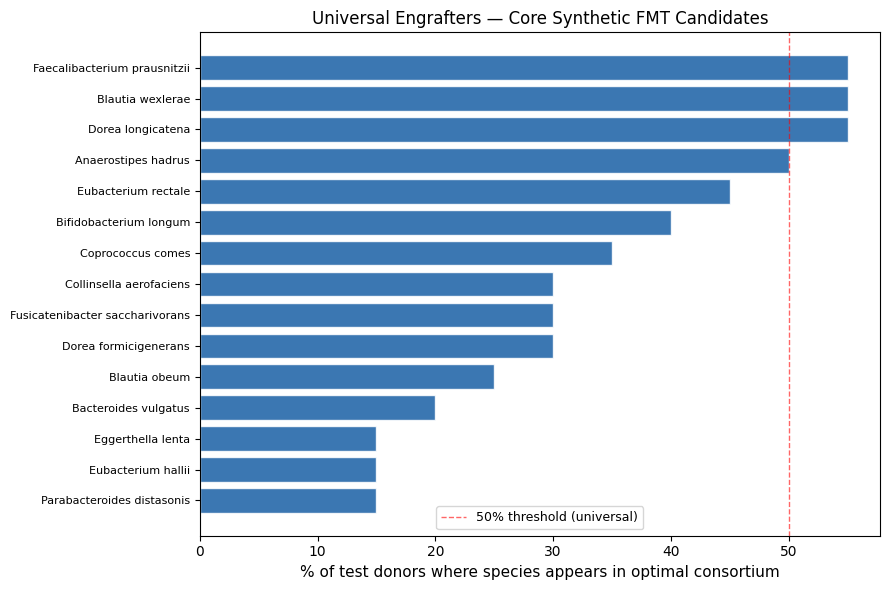

Fig_universal_engrafters.png saved


In [8]:
import matplotlib.pyplot as plt

freq = (
    final_consortia
    .groupby('species')
    .agg(
        n_donors   =('donor_id',   'nunique'),
        mean_cece  =('cece_score', 'mean'),
        mean_fitness=('ga_fitness', 'mean')
    )
    .sort_values('n_donors', ascending=False)
)

n_total = final_consortia['donor_id'].nunique()
freq['pct_donors'] = (freq['n_donors'] / n_total * 100).round(1)

freq.to_csv('../results/universal_engrafters.csv')

print(f'Total donors: {n_total}')
print(f'Universal engrafters (>50% donors): '
      f'{(freq["n_donors"] > n_total // 2).sum()}')
print(f'\nTop 20 most frequent species in optimal consortia:')
print(freq.head(20).to_string())

top15 = freq.head(15).sort_values('n_donors', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

bars = ax.barh(
    [sp.replace('_', ' ')[:35] for sp in top15.index],
    top15['pct_donors'],
    color='#185FA5', alpha=0.85, edgecolor='white'
)
ax.axvline(50, color='red', linestyle='--', lw=1, alpha=0.6,
           label='50% threshold (universal)')
ax.set_xlabel('% of test donors where species appears in optimal consortium',
              fontsize=11)
ax.set_title('Universal Engrafters — Core Synthetic FMT Candidates', fontsize=12)
ax.legend(fontsize=9)
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('../figures/final/Fig_universal_engrafters.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('Fig_universal_engrafters.png saved')